<a href="https://colab.research.google.com/github/qrvdelossantos/CPE-311/blob/main/Hands_on_Activity_10_1_Data_Analysis_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_excel("Survey on Generative AI Usage among Gen Z.xlsx", sheet_name="Cleaned Data")
df = df.dropna(how="all")
print(df.head())





   Age  Gender   What is the highest level of education you have completed?\n  \
0    1        2                                                  4              
1    1        1                                                  5              
2    1        1                                                  4              
3    1        2                                                  1              
4    1        1                                                  4              

   What is your Current Occupation?\n  \
0                                   2   
1                                   1   
2                                   1   
3                                   1   
4                                   1   

      What is your average monthly Income?\n  \
0                                          1   
1                                          1   
2                                          1   
3                                          1   
4                         

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())








['age', 'gender', 'what_is_the_highest_level_of_education_you_have_completed?', 'what_is_your_current_occupation?', 'what_is_your_average_monthly_income?', 'how_often_do_you_typically_use_generative_ai_tools?', 'i_find_generative_ai_tools_very_useful_for_my_daily_tasks/learning', 'using_generative_ai_increases_my_efficiency_in_my_daily_work', 'using_generative_ai_tools_helps_me_accomplish_my_tasks_more_quickly', 'using_generative_ai_tools_increases_my_productivity', 'learning_how_to_use_generative_ai_tools_is_easy_for_me', 'my_interaction_with_generative_ai_tools_is_clear_and_understandable', 'i_find_generative_ai_tools_easy_to_use', 'it_is_easy_for_me_to_become_skillful_at_using_generative_ai_tools', 'i_have_the_necessary_resources_(devices/internet)_to_use_generative_ai', 'i_have_the_necessary_knowledge_to_use_generative_ai_tools_effectively', 'generative_ai_is_compatible_with_the_other_technologies_that_i_use', 'i_can_get_help_from_others_when_i_have_difficulties_using_generative_ai

In [ ]:

print("Age distribution:\n", df['age'].value_counts())
print("\nGender distribution:\n", df['gender'].value_counts())
print("\nEducation distribution:\n", df['what_is_the_highest_level_of_education_you_have_completed?'].value_counts())
print("\nOccupation distribution:\n", df['what_is_your_current_occupation?'].value_counts())
print("\nIncome distribution:\n", df['what_is_your_average_monthly_income?'].value_counts())
usage_counts = df.groupby(["what_is_your_current_occupation?", "how_often_do_you_typically_use_generative_ai_tools?"]).size().unstack(fill_value=0)
print("\nUsage frequency by occupation:\n", usage_counts)









Age distribution:
 age
1    151
2     24
4      3
3      1
Name: count, dtype: int64

Gender distribution:
 gender
1    101
2     78
Name: count, dtype: int64

Education distribution:
 what_is_the_highest_level_of_education_you_have_completed?
4    85
5    35
2    30
1    21
3     7
6     1
Name: count, dtype: int64

Occupation distribution:
 what_is_your_current_occupation?
1    137
2     29
4      9
3      4
Name: count, dtype: int64

Income distribution:
 what_is_your_average_monthly_income?
1    147
2     13
5      7
4      6
3      6
Name: count, dtype: int64

Usage frequency by occupation:
 how_often_do_you_typically_use_generative_ai_tools?  1   2   3   4   5
what_is_your_current_occupation?                                      
1                                                    7  17  45  43  25
2                                                    2   9   9   4   5
3                                                    0   2   1   1   0
4                                        

In [ ]:
likert_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neither agree nor disagree": 3,
    "Agree": 4,
    "Strongly agree": 5
}

df_numeric = df.replace(likert_map)

corr_matrix = df_numeric.corr()
print(corr_matrix)



                                                         age    gender  \
age                                                 1.000000 -0.048904   
gender                                             -0.048904  1.000000   
what_is_the_highest_level_of_education_you_have...  0.124947 -0.339778   
what_is_your_current_occupation?                    0.375858 -0.072562   
what_is_your_average_monthly_income?                0.251937 -0.136098   
how_often_do_you_typically_use_generative_ai_to... -0.035781 -0.121809   
i_find_generative_ai_tools_very_useful_for_my_d...  0.043663 -0.027702   
using_generative_ai_increases_my_efficiency_in_...  0.254319  0.020002   
using_generative_ai_tools_helps_me_accomplish_m...  0.066116 -0.149195   
using_generative_ai_tools_increases_my_producti...  0.194112 -0.148902   
learning_how_to_use_generative_ai_tools_is_easy...  0.181212 -0.097690   
my_interaction_with_generative_ai_tools_is_clea...  0.124848 -0.100255   
i_find_generative_ai_tools_easy_to_use

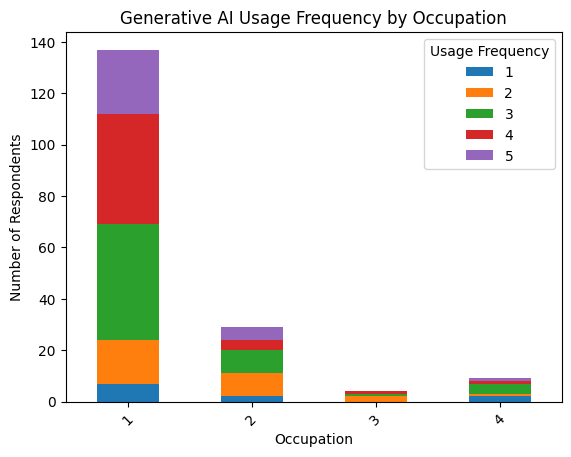

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart: AI usage frequency by occupation
usage_counts.plot(kind="bar", stacked=True)
plt.title("Generative AI Usage Frequency by Occupation")
plt.ylabel("Number of Respondents")
plt.xlabel("Occupation")
plt.xticks(rotation=45)
plt.legend(title="Usage Frequency")
plt.show()





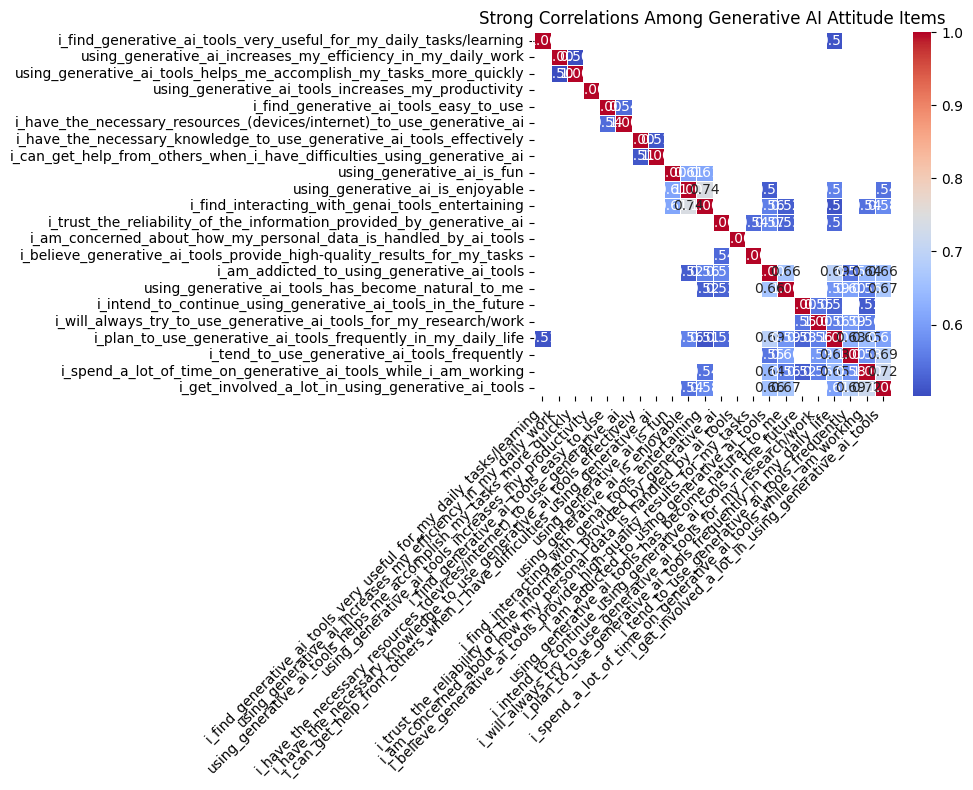

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix for Likert items only
likert_cols = [col for col in df_numeric.columns if col.startswith('i_') or col.startswith('using_')]
corr_matrix = df_numeric[likert_cols].corr()

# Mask weak correlations (< 0.5)
mask = corr_matrix.abs() < 0.5
filtered_corr = corr_matrix.mask(mask)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(filtered_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Strong Correlations Among Generative AI Attitude Items")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




## **Conclusion** <br>
*The survey results highlight that most Gen Z respondents use generative AI primarily for academic and productivity purposes, typically spending 1–5 hours per week with these tools. Usage frequency varies across occupations and education levels, with students and higher educated groups reporting more consistent engagement. Correlation analysis shows strong links between perceived productivity benefits and intentions to continue using AI, while privacy concerns appear less influential on actual usage.
It is worth noting that the correlation heatmap produced during analysis appeared messy and cluttered. This happened because too many variables demographics and numerous Likertscale items were included in a single matrix. As a result, the visualization became difficult to interpret, with overlapping labels and excessive detail. This limitation underscores the importance of filtering variables or focusing only on the strongest correlations when presenting complex survey data.*